#### EDA 2
Hacer los siguiente grafos:
* Borrar enero y hacer Productos perdidos mensuales (con promedio en linea horizonatal)
* Crear ingresos de ventas en df original 
    - Ver cuales son los que traen mas ingresos en total
    - Ver cuales son los que traen mas ingresos en cada mes
* HAcer arriba igual con popularidad
* HACER ARPU mensual sin enero

In [1]:
##### Importacion de modulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import os

##### Cambiando directorio
print(os.getcwd())
if os.getcwd().split('\\')[-1] != 'PostSQL':
    os.chdir('./Datos/PostSQL')


c:\Users\JP\Documents\DSProyectos\4_DemandaForecasting


In [2]:
##### Leyendo y Cargando datos
df = pd.read_csv('ventas_productos.csv')
# df.info()


##### Fechas y Datetime
#### Transformanco fechas a DateTime
df['fecha'] = pd.to_datetime(
    df['fecha'],
    format='%d/%m/%Y',
    dayfirst=True,
    errors='coerce'
)
#### Verificando que todos los datos son del anio 2024
print(df['fecha'].dt.year.unique().tolist())
#### Creando columnas: dia, semana, mes
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.weekday + 1
df['semana'] = df['fecha'].dt.isocalendar().week
df['mes'] = df['fecha'].dt.month
#### Ordenando datos por fecha
df = df.drop(columns='fecha')\
    .sort_values(by=['mes','dia'], ascending=[True, True])
#### Rango de fechas: 31/1/24 - 30/12/24
    # 31/1/24 se traslada a la 5ta semana del anio 2024
    # PERO 30/12/25 se traslada a la 1ra semana del anio 2025
        # Ende: Borrar
df = df[~((df['dia']==30) & (df['mes']==12))]
#### MEs de Enero
    # Los datos del mes de enero estan incompletos
    # Se van a borrar
df = df.drop(df[df['mes']==1].index)
#### Reseteo de los indices
df = df.reset_index(drop=True)


##### Creando categoria de ingresos
df['ingreso'] = df['cantidad'] * df['precio']


##### Stock
    # El valor de 'stock' es un valor para todo el anio
        # Entonces para diferentes granularidades se tiene
                # que hacer una division igual entre ellas
# len(df['stock'].unique())
# df['stock'] = (df['stock']/52).astype(int)


#### Resumen
df.info()


[2024]
<class 'pandas.DataFrame'>
RangeIndex: 2986 entries, 0 to 2985
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_venta    2986 non-null   int64 
 1   cliente_id  2986 non-null   int64 
 2   cantidad    2986 non-null   int64 
 3   stock       2986 non-null   int64 
 4   nombre      2986 non-null   str   
 5   categoria   2986 non-null   str   
 6   precio      2986 non-null   int64 
 7   dia         2986 non-null   int32 
 8   dia_semana  2986 non-null   int32 
 9   semana      2986 non-null   UInt32
 10  mes         2986 non-null   int32 
 11  ingreso     2986 non-null   int64 
dtypes: UInt32(1), int32(3), int64(6), str(2)
memory usage: 236.3 KB


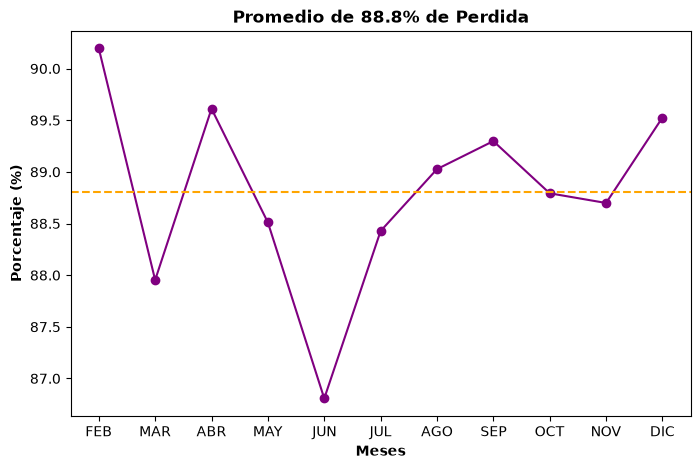

In [82]:
##### Productos perdidos: Mensuales
#### Creacion de datos
df_mncs = df\
    .groupby(by=['mes', 'nombre'], as_index=False)\
    .agg(
        cantidad_vendida = pd.NamedAgg(
            column='cantidad', aggfunc= lambda series: series.sum()
        ),
        producto_stock = pd.NamedAgg(
            column='stock', aggfunc= lambda series: int(series.mean()/12)
        )
    )

#### Creacion de metrica PPP
df_mncs['PPP'] = (
    (
        (df_mncs['producto_stock'] - df_mncs['cantidad_vendida'])/df_mncs['producto_stock']
    ) * 100
).round(2)

#### PPP mesuales
df_ppp_mens = df_mncs\
    .groupby(by='mes', as_index=False)\
    .agg(
        ppp_mensual = pd.NamedAgg(
            column='PPP', aggfunc= lambda series: series.mean()
        )
    ).sort_values(by='mes', ascending=True)


# display(df_mncs)

##### Creando visual
#### Config inicial
ANCH = 8
ALT = 5
fig, ax = plt.subplots(figsize=(ANCH,ALT))
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Visual
ax.plot(
    range(len(meses)),
    df_ppp_mens['ppp_mensual'],
    marker='o',
    color = 'purple'
)
ax.axhline(y=df_ppp_mens['ppp_mensual'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Promedio de todos' )
#### Configs finales
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses)
ax.set_xlabel('Meses', fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontweight='bold')
ax.set_title(f'Promedio de {df_ppp_mens['ppp_mensual'].mean().round(2)}% de Perdida', fontweight='bold')
plt.show()

Text(0.5, 1.0, 'Un Promedio de 88.8% del Stock Anual se Pierde')

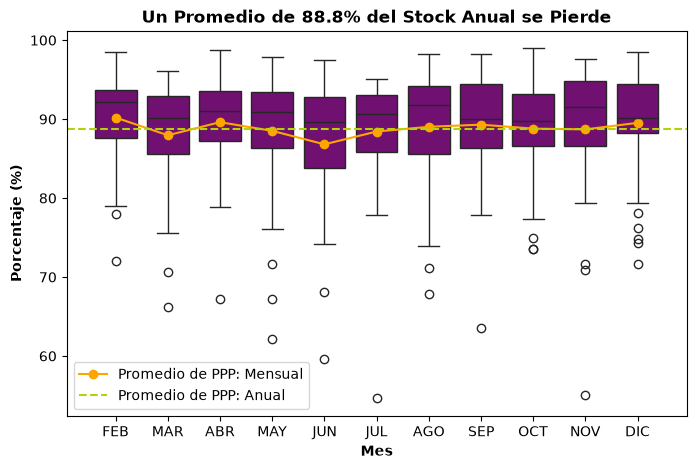

In [105]:
##### Productos perdidos: Mensuales
#### Creacion de datos
df_mncs = df\
    .groupby(by=['mes', 'nombre'], as_index=False)\
    .agg(
        cantidad_vendida = pd.NamedAgg(
            column='cantidad', aggfunc= lambda series: series.sum()
        ),
        producto_stock = pd.NamedAgg(
            column='stock', aggfunc= lambda series: int(series.mean()/12)
        )
    )

#### Creacion de metrica PPP
df_mncs['PPP'] = (
    (
        (df_mncs['producto_stock'] - df_mncs['cantidad_vendida'])/df_mncs['producto_stock']
    ) * 100
).round(2)

##### Boxplots
#### configs inciales
ANCH = 8
ALT = 5
fig, ax = plt.subplots(figsize=(ANCH,ALT))
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Grafico
sns.boxplot(
    x='mes', y='PPP', 
    data=df_mncs[['mes','PPP']],
    ax=ax,
    color = 'purple'
)
promedio_meses = df_mncs\
    .groupby(by='mes')\
    ['PPP'].mean()
ax.plot(
    range(len(meses)),
    promedio_meses,
    color='orange',
    marker='o',
    label= 'Promedio de PPP: Mensual'
)
ax.axhline(
    promedio_meses.mean(),
    color = "#b4d10e",
    linestyle='--', 
    linewidth=1.5, 
    label='Promedio de PPP: Anual'
)
#### Configs finales
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses)
ax.set_xlabel('Mes', fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontweight='bold')
ax.legend()
ax.set_title(f'Un Promedio de {promedio_meses.mean().round(2)}% del Stock Anual se Pierde', fontweight='bold')


In [79]:
# ###### Rank de los top 5 mas PPX y PIX
# ##### Seleccion de datos
# df_nc = df\
#     .groupby(by='nombre', as_index=False)\
#     .agg(
#         cantidad_suma = pd.NamedAgg(
#             column='cantidad', aggfunc= lambda series: series.sum()
#         ),
#         ingreso_suma = pd.NamedAgg(
#             column='ingreso', aggfunc= lambda series: series.sum()
#         )
#     )

# ##### Creando metricas
# #### PPX
# df_nc['PPX'] = (
#     (df_nc['cantidad_suma']/df_nc['cantidad_suma'].sum()) * 100
# ).round(2)
# #### PIX
# df_nc['PIX'] = (
#     (df_nc['ingreso_suma']/ df_nc['ingreso_suma'].sum()) * 100
# ).round(2)

# ##### Seleccionando top X
# top_X = 5
# #### top X PPX
# top_X_PPX = df_nc\
#     .sort_values(by='PPX', ascending=False)
#     # ['nombre'][:top_X].values.tolist()
# #### top X PIX
# top_X_PIX = df_nc\
#     .sort_values(by='PIX', ascending=False)
#     # ['nombre'][:top_X].values.tolist()

# # display(top_X_PPX)
# # display(top_X_PIX)


# ##### Creando figura
# #### Config inicial
# ANCH = 8
# ALT = 5
# WIDTH=0.15
# rank = [f'Top {i}' for i in range(1,6,1)]
# fig, ax1 = plt.subplots(figsize=(ANCH, ALT))
# colores = ["#d1650c", "#05a07e",\
#             "#be0e57", "#5b7a06"]
# grafos = ['PPX', 'PIX']
# if len(grafos) % 2 == 0:
#     centro = list(range(-1*int(len(grafos)/2),int(len(grafos)/2),1))
# else:
#     centro = list(range(-1*int(len(grafos)/2),int(len(grafos)/2) + 1,1))


# #### Grafica - PPX
# ### Grafica
# PPX_barras = ax1.bar(
#     np.arange(len(rank)) + centro[0]*WIDTH,
#     top_X_PPX['PPX'][:top_X].values.tolist(),
#     label='Popularidad de un Producto',
#     width = WIDTH,
#     color = colores[0],
#     edgecolor='black',
#     align='center'
# )
# ### Valor textual
# ax1.bar_label(
#     PPX_barras,
#     labels=[f' {nom} - {porc}%' for (nom, porc) in zip(
#         top_X_PPX['nombre'][:top_X].values.tolist(), 
#         top_X_PPX['PPX'][:top_X].values.tolist()
#     )],
#     label_type='edge',  #'edge
#     color = 'black',
#     fontsize= 10,
#     rotation = 90
# )

# #### Grafica - PIX
# ### grafica
# ax2 = ax1.twinx()
# PIX_barras = ax2.bar(
#     np.arange(len(rank)) + centro[1]*WIDTH,
#     top_X_PIX['PIX'][:top_X].values.tolist(),
#     label='Ingresos de un Producto',
#     width = WIDTH,
#     color = colores[1],
#     edgecolor='black',
#     align='center'
# )
# ### Valor textual
# ax2.bar_label(
#     PIX_barras,
#     labels=[f'{nom} - {porc}%' for (nom, porc) in zip(
#         top_X_PIX['nombre'][:top_X].values.tolist(),
#         top_X_PIX['PIX'][:top_X].values.tolist()
#     )],
#     label_type='center',  #'edge
#     color = 'black',
#     fontsize= 9.5,
#     rotation = 90,
# )

# #### Configuraciones finales
# ### ax1
# ax2.set_ylim(0,max( top_X_PIX['PIX'][:top_X].values.tolist())+2)
# ax1.set_ylim(ax2.get_ylim())
# ax1.set_ylabel('Porcentaje(%) de Ventas Anuales', color = colores[0], fontweight='bold')
# ax1.tick_params(axis='y', labelcolor=colores[0])
# ax1.set_xlabel('Rank', fontweight='bold')
# ### ax2
# ax2.set_ylabel('Porcentaje(%) de Ingreso Anuales', color = colores[1], fontweight='bold')
# ax2.tick_params(axis='y', labelcolor=colores[1])
# ### General
# fig.suptitle(f'Top {top_X} Productos - Por Popularidad e Ingresos', fontweight='bold')
# ax1.set_xticks(range(len(rank)))
# ax1.set_xticklabels(rank)

# #### Uniendo leyendas
# handles1, labels1 = ax1.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()

# # Combinar y mostrar en un solo lugar
# ax1.legend(handles1 + handles2, labels1 + labels2, 
#            loc='upper center', title='Metricas',
#            bbox_to_anchor=(0.47, 1.0))



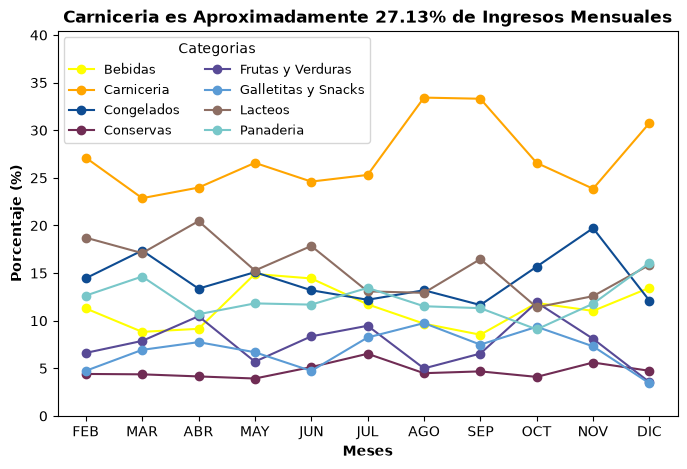

In [85]:
###### Categoria vs Ingreso
    # Ver cual % del ingreso mensual es contribuido por cada categoria
##### Seleccion de datos
df_mc = df\
    .groupby(by=['mes', 'categoria'], as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )

##### Haciendo porcentaje mensual de cada categoria
df_mc['porcentaje'] = (
    (
        df_mc['ingreso_mensual'] / \
        df_mc.groupby(by='mes')['ingreso_mensual'].transform(
            lambda series: series.sum()
        )
    ) * 100
).round(2)


##### Creando visual
#### Config inicial
ANCH = 8
ALT = 5
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
categorias = df_mc['categoria'].unique()
colores = ["#ffff00", "#ffa500", "#0e4c92", "#702c54", "#584A96",\
        '#5b9bd5', '#8d6e63', '#78C7C9', '#6FA0C8', '#7E77B8',\
        '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
        '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
        '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
        '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
        "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
fig, ax = plt.subplots(figsize=(ANCH,ALT))
#### Figura
for i, cat in enumerate(categorias):
    ax.plot(
        range(len(meses)),
        df_mc[df_mc['categoria']==cat]['porcentaje'],
        label = cat,
        marker='o',
        color = colores[i]
    )
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses)
ax.set_xlabel('Meses', fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontweight='bold')
promedio = df_mc[df_mc['categoria'] == 'Carniceria']['porcentaje'].mean().round(2)
ax.set_title(f'Carniceria es Aproximadamente {promedio}% de Ingresos Mensuales',fontweight='bold')
ax.legend(ncol=2, title='Categorias', fontsize=9)
ax.set_ylim(0, max(df_mc['porcentaje']) + 7)
plt.show()



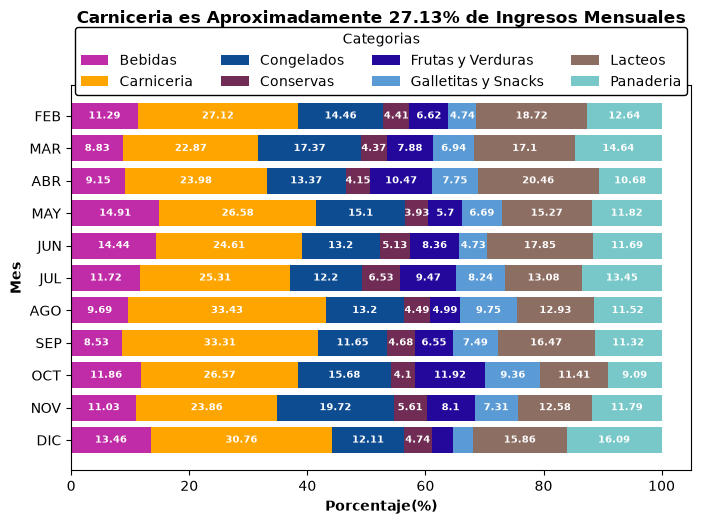

In [106]:
###### Categoria vs Ingreso
    # Ver cual % del ingreso mensual es contribuido por cada categoria
##### Seleccion de datos
df_mc = df\
    .groupby(by=['mes', 'categoria'], as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )

##### Haciendo porcentaje mensual de cada categoria
df_mc['porcentaje'] = (
    (
        df_mc['ingreso_mensual'] / \
        df_mc.groupby(by='mes')['ingreso_mensual'].transform(
            lambda series: series.sum()
        )
    ) * 100
).round(2)

# display(df_mc)

##### Creando visual
#### Config inicial
ANCH = 8
ALT = 5
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
categorias = df_mc['categoria'].unique()
y_pos = np.arange(len(meses))
left_accum = np.zeros(len(meses))
colores = ["#c02ba7", "#ffa500", "#0e4c92", "#702c54", "#23089B",\
        '#5b9bd5', '#8d6e63', '#78C7C9', '#6FA0C8', '#7E77B8',\
        '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
        '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
        '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
        '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
        "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
fig, ax = plt.subplots(figsize=(ANCH,ALT))
#### Figura
for i, cat in enumerate(categorias):
    ### Creando datos de esta iteracion
    valores = df_mc[df_mc['categoria']==cat]['porcentaje'].values.tolist()
    ### Creando las barras
    barras = ax.barh(
        y_pos,
        valores,
        left = left_accum,
        color = colores[i],
        label = cat
    )
    ### Creando el texto
    for bar, valor in zip(barras, valores):
        x_center = bar.get_x() + bar.get_width() / 2
        y_center = bar.get_y() + bar.get_height() / 2
        ax.text(
            x_center, y_center,
            f"{valor}" if valor > 3.56 else "",  # Texto a mostrar
            ha="center", va="center",
            color="white", fontsize=7, fontweight="bold"
        )
    left_accum += valores
ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels(meses)
ax.set_ylabel('Mes', fontweight='bold')
# ax.set_ylim(0,len(categorias)-2)
ax.set_xlabel('Porcentaje(%)', fontweight='bold')
promedio = df_mc[df_mc['categoria'] == 'Carniceria']['porcentaje'].mean().round(2)
ax.set_title(f'Carniceria es Aproximadamente {promedio}% de Ingresos Mensuales',fontweight='bold', pad = 45)
ax.legend(
    ncols=int(len(categorias)/2), 
    loc='upper center', 
    bbox_to_anchor=(0.5,1.17), 
    title='Categorias',
    edgecolor='black',
    framealpha=1.0
)
plt.show()



In [78]:
# ###### Categoria vs Cantidad - Popularidad
#     # Ver cual % del cantidad mensual es contribuido por cada categoria
# ##### Seleccion de datos
# df_mc = df\
#     .groupby(by=['mes', 'categoria'], as_index=False)\
#     .agg(
#         cantidad_mensual = pd.NamedAgg(
#             column='cantidad', aggfunc= lambda series: series.sum()
#         )
#     )

# ##### Haciendo porcentaje mensual de cada categoria
# df_mc['porcentaje'] = (
#     (
#         df_mc['cantidad_mensual'] / \
#         df_mc.groupby(by='mes')['cantidad_mensual'].transform(
#             lambda series: series.sum()
#         )
#     ) * 100
# ).round(2)


# ##### Creando visual
# #### Config inicial
# ANCH = 8
# ALT = 5
# meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
#          'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
# categorias = df_mc['categoria'].unique()
# colores = ["#ffff00", "#ffa500", "#0e4c92", "#702c54", "#584A96",\
#         '#5b9bd5', '#8d6e63', '#78C7C9', '#6FA0C8', '#7E77B8',\
#         '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
#         '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
#         '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
#         '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
#         "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
# fig, ax = plt.subplots(figsize=(ANCH,ALT))
# #### Figura
# for i, cat in enumerate(categorias):
#     ax.plot(
#         range(len(meses)),
#         df_mc[df_mc['categoria']==cat]['porcentaje'],
#         label = cat,
#         marker='o',
#         color = colores[i]
#     )
# ax.set_xticks(range(len(meses)))
# ax.set_xticklabels(meses)
# ax.legend(ncol=2, title='Categorias', fontsize=9)
# ax.set_ylim(0, max(df_mc['porcentaje']) + 7)
# plt.show()

,mes,cliente_id,ingreso_mensual
0,2,1,56800
1,2,3,36000
2,2,5,25400
3,2,6,22800
4,2,8,25200
...,...,...,...
2030,12,321,50000
2031,12,322,10400
2032,12,323,27600
2033,12,325,30000


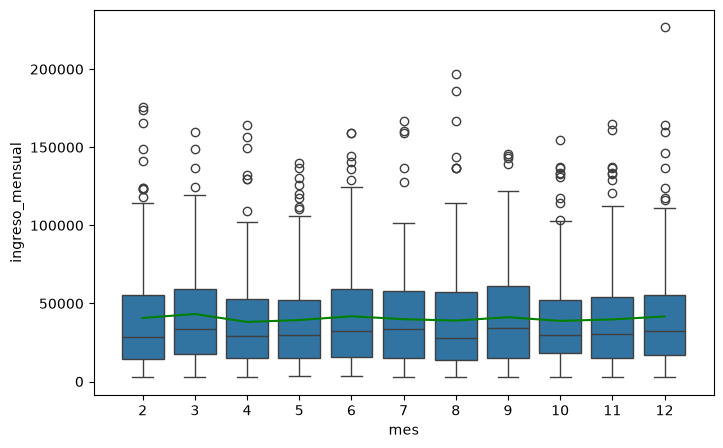

,mes,arpu_mensual,cantidad_clientes
0,2,40705.85,171
1,3,43209.14,186
2,4,38131.69,183
3,5,39350.79,189
4,6,41763.45,197
5,7,39911.58,190
6,8,39010.81,185
7,9,41155.68,185
8,10,38818.72,187
9,11,39761.24,178


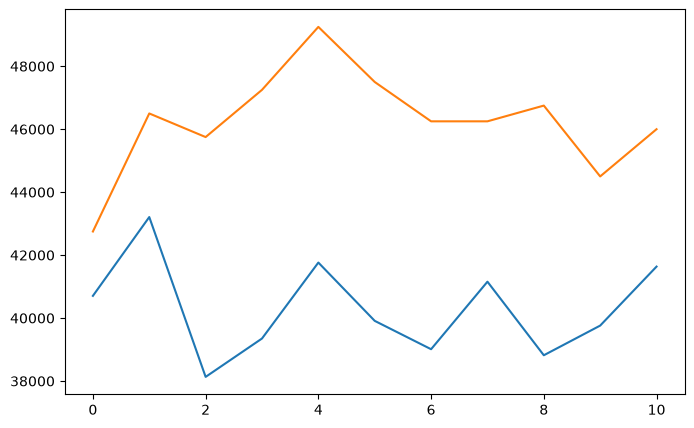

In [115]:
###### ARPU Box plots
##### Seleccionando datos
#### Datos genera
df_mcl=df\
    .groupby(by=['mes','cliente_id'], as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )
display(df_mcl)

#### Datos arpu
df_arpu = df_mcl\
    .groupby(by='mes', as_index=False)\
    .agg(
        arpu_mensual = pd.NamedAgg(
            column='ingreso_mensual', aggfunc= lambda series: series.mean().round(2)
        ),
        cantidad_clientes = pd.NamedAgg(
            column='cliente_id', aggfunc=lambda series: series.count()
        ),
    )
##### Boxplots
ANCH = 8
ALT = 5
fig, ax = plt.subplots(figsize=(ANCH,ALT))
sns.boxplot(
    x='mes', y='ingreso_mensual', 
    data=df_mcl[['mes','ingreso_mensual']],
    ax=ax
)
sns.lineplot(
    x=range(11), y = 'arpu_mensual',
    data=df_arpu,
    color='green',
    ax=ax
)
plt.show()


###### Linegraph
plt.figure(figsize=(ANCH,ALT))
plt.plot(
    range(len(df_arpu['mes'])),
    df_arpu['arpu_mensual']
)
plt.plot(
    range(len(df_arpu['mes'])),
    df_arpu['cantidad_clientes']*250
)
display(df_arpu)


,mes,ingreso_mensual,cantidad_clientes,arpu_mensual
0,2,6960700,171,40705.85
1,3,8036900,186,43209.14
2,4,6978100,183,38131.69
3,5,7437300,189,39350.79
4,6,8227400,197,41763.45
5,7,7583200,190,39911.58
6,8,7217000,185,39010.81
7,9,7613800,185,41155.68
8,10,7259100,187,38818.72
9,11,7077500,178,39761.24


Text(0.5, 0.98, '4 Meses del Anio con Altos ARPUs')

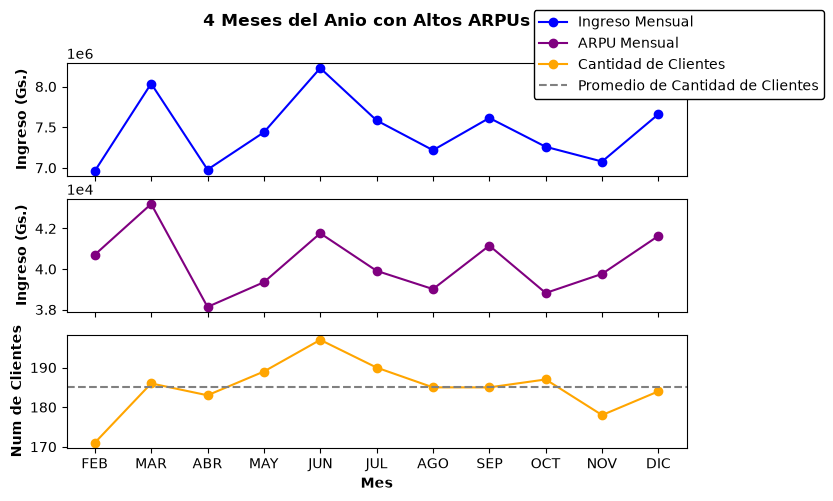

In [87]:
###### ARPU Box plots
##### Seleccionando datos
#### Datos genera
df_mcl=df\
    .groupby(by=['mes','cliente_id'], as_index=False)\
    .agg(
        ingreso_mensual_por_cliente = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )
# display(df_mcl)

#### Datos arpu
df_arpu = df_mcl\
    .groupby(by='mes', as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso_mensual_por_cliente', aggfunc=lambda series: series.sum()
        ),
        cantidad_clientes = pd.NamedAgg(
            column='cliente_id', aggfunc=lambda series: series.count()
        ),
        arpu_mensual = pd.NamedAgg(
            column='ingreso_mensual_por_cliente', aggfunc= lambda series: series.mean().round(2)
        ),
    )

display(df_arpu)

##### Grafica
#### Config inicial
ANCH = 8
ALT = 5
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(ANCH, ALT), sharex=True)
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Creando la grafica
### Ingreso Mensual
axs[0].plot(
    range(len(meses)),
    df_arpu['ingreso_mensual'],
    label='Ingreso Mensual',
    marker='o',
    color='blue'
)
### ARPU Mensual
axs[1].plot(
    range(len(meses)),
    df_arpu['arpu_mensual'],
    label='ARPU Mensual',
    marker='o',
    color='purple'
)
### Cantidad de Clientes
axs[2].plot(
    range(len(meses)),
    df_arpu['cantidad_clientes'],
    label='Cantidad de Clientes',
    marker='o',
    color='orange'
)
#### Configs finales
# ax.axhline(y=df_ppp_mens['ppp_mensual'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Promedio de todos' )
axs[2].axhline(
    df_arpu['cantidad_clientes'].mean(),
    color = 'grey',
    linestyle='--', 
    linewidth=1.5, 
    label='Promedio de Cantidad de Clientes'
)
### ax2
axs[2].set_xticks(range(len(meses)))
axs[2].set_xticklabels(meses)
axs[2].set_xlabel('Mes', fontweight='bold')
axs[2].set_ylabel('Num de Clientes', fontweight='bold')
### ax1
axs[1].set_ylabel('Ingreso (Gs.)', fontweight='bold')
axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
### ax0
axs[0].set_ylabel('Ingreso (Gs.)', fontweight='bold')
fig.legend(
    loc='upper left', 
    bbox_to_anchor=(0.7,1.0), 
    framealpha=1.0,
    edgecolor='black'
)
fig.suptitle('4 Meses del Anio con Altos ARPUs', fontweight='bold')
